In [ ]:
! pip install info-nce-pytorch

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path

import sys
sys.path.append('../../')

import phys_ml.visualization.vertex_visualization as vertvis
import phys_ml.visualization.base as vis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

In [ ]:
from sklearn import ensemble, svm


# load vertices
path_train = '../../../frgs_6d'
file_paths = AutoEncoderVertex24x6Dataset.get_filepaths(path_train, subset=None, subset_shuffle=False)[0]
vertices = AutoEncoderVertex24x6Dataset.load_vertex_files(file_paths)


info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32]
config_kwargs = {
    'hidden_dims': hidden_dims,
    'epochs': 1000,
    'test_ratio': 0.2, 
    'devices': 'auto', 
    'num_dataloader_workers': 8, 
    'strategy': 'auto', 
    'batch_size': 8192
}
dataset_kwargs = {
    'path_train': path_train, 
    'subset_shuffle': False, 
}

seed = 12
train_samples_per_vertex = 24000
test_samples_per_vertex = 2000


def make_dataset(subset: int|None = None, subset_type: str|list[str]|None = None, 
                 sample_count_per_vertex: int = train_samples_per_vertex, 
                 dataset_class: type[AutoEncoderVertex24x6Dataset] = AutoEncoderVertex24x6Dataset,
                 return_filepaths: bool = True) -> AutoEncoderVertex24x6Dataset:
    config = Vertex24x6Config(subset=subset, subset_type=subset_type, sample_count_per_vertex=sample_count_per_vertex, **dataset_kwargs)
    return dataset_class(config, vertices, return_filepaths=return_filepaths)


def init_trainer(dataset: AutoEncoderVertex24x6Dataset, device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    kws = config_kwargs.copy()
    kws.update(dataset_kwargs)
    kws['device_type'] = device_type
    for k, v in kwargs.items():
        kws[k] = v
    kws['subset_type'] = dataset.config.subset_type
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', dataset=dataset,
                                config_kwargs=kws)
    return trainer

test_dataset = make_dataset(sample_count_per_vertex=test_samples_per_vertex, dataset_class=AutoEncoder24x6InfoNCEDataset)

In [ ]:
# back_up existing info_files
info_fn = 'eval_info.pkl'
verteval.backup_info(info_fn)

# 04 Phase classification

In [4]:
pc_models = [
    # svm.SVC(verbose=True, random_state=seed + 1), 
    ensemble.RandomForestClassifier(n_jobs=-1, verbose=0, random_state=seed + 2),
]

## 04-1 All vertices

* evaluate amount of information captured in latent space
* see how well the phase can be classified from the latent space

In [ ]:
train_dataset = make_dataset()
nce_train_dataset = make_dataset(sample_count_per_vertex=train_samples_per_vertex // 4, dataset_class=AutoEncoder24x6InfoNCEDataset)

In [ ]:
trainer = init_trainer(train_dataset)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [5]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_1'

### 04-1-0 default

In [33]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_1'
pc = PhaseClassification(save_path, pc_models, 10)

In [ ]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/15 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

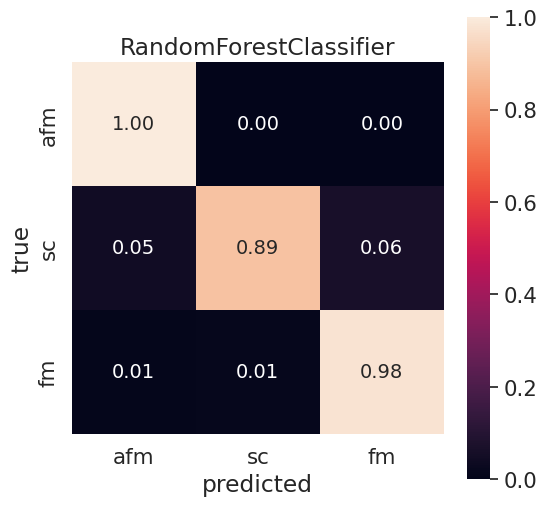

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9561041666666666),
   'prec': 0.9561041666666666,
   'rec': 0.9561041666666666,
   'f1': 0.9561041666666666},
  array([[1.        , 0.        , 0.        ],
         [0.04653125, 0.8908125 , 0.06265625],
         [0.00866875, 0.01383125, 0.9775    ]]))}

In [40]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
model_scores

### 04-1-1 train classifier on uncompressed vertex-samples

In [48]:
pc = PhaseClassification(None, pc_models, 11)

In [ ]:
pc.train(nce_train_dataset)

Load vertex samples:   0%|          | 0/59 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

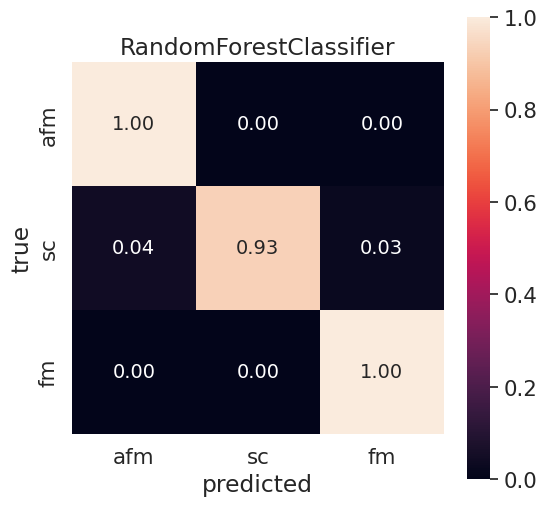

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9764937499999999),
   'prec': 0.97649375,
   'rec': 0.97649375,
   'f1': 0.97649375},
  array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [4.3806250e-02, 9.3067500e-01, 2.5518750e-02],
         [4.3750000e-05, 1.1500000e-03, 9.9880625e-01]]))}

In [51]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'1-1_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 04-1-2 train with Neural Network on uncompressed vertices

In [ ]:
in_dim = 24 * 6
net = phase_classification.NeuralNetClassifier(in_dim, [96, 48], 3, batch_size=config_kwargs['batch_size'], 
                                               num_workers=config_kwargs['num_dataloader_workers'], max_epochs=config_kwargs['epochs'])
pc = PhaseClassification(None, [net], 12)

In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/51 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

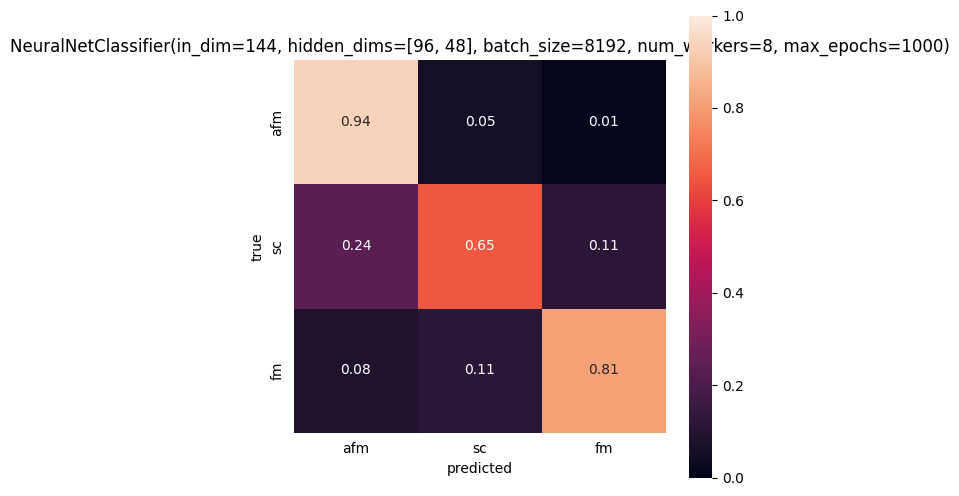

{'NeuralNetClassifier(in_dim=144, hidden_dims=[96, 48], batch_size=8192, num_workers=8, max_epochs=1000)': ({'acc': np.float64(0.7989808404558404),
   'prec': 0.8189705882352941,
   'rec': 0.8189705882352941,
   'f1': 0.8189705882352941},
  array([[0.936075  , 0.052325  , 0.0116    ],
         [0.23580769, 0.64992308, 0.11426923],
         [0.07905556, 0.11      , 0.81094444]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'1-2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 04-1-3 Use contrastive Autoencoder and classifer on latent space

In [ ]:
nce_train_dataset = make_dataset(sample_count_per_vertex=6000, dataset_class=AutoEncoder24x6InfoNCEDataset)

In [ ]:
trainer = init_trainer(nce_train_dataset, model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', batch_size=4096)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at /gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-04-19/version_4/checkpoints/epoch=983-step=369000.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-04-19/version_4/checkpoints/epoch=983-step=369000.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

/home/fs71925/shepp123/.local/lib/python3.11/site-packages/lightning/pytorch/loops/prediction_loop.py:255: predict returned None if it was on purpose, ignore this warning...


RESULTS:
   latent_dim=s=24000,e=100: RMSE=0.0416


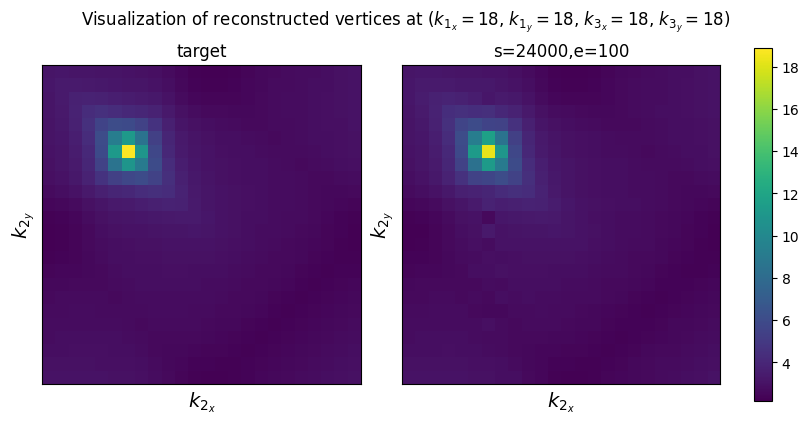

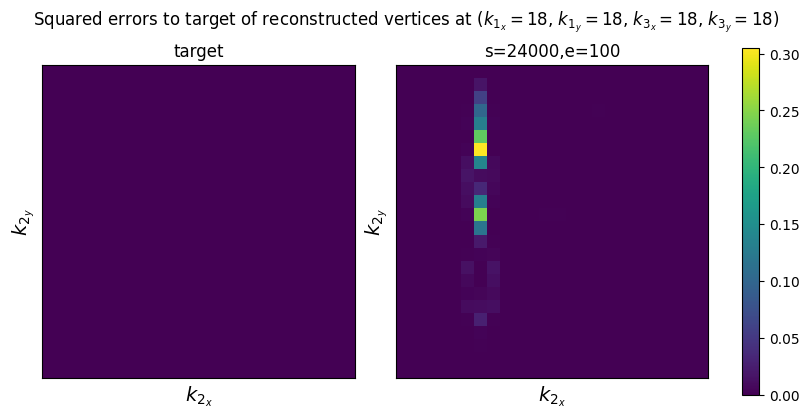

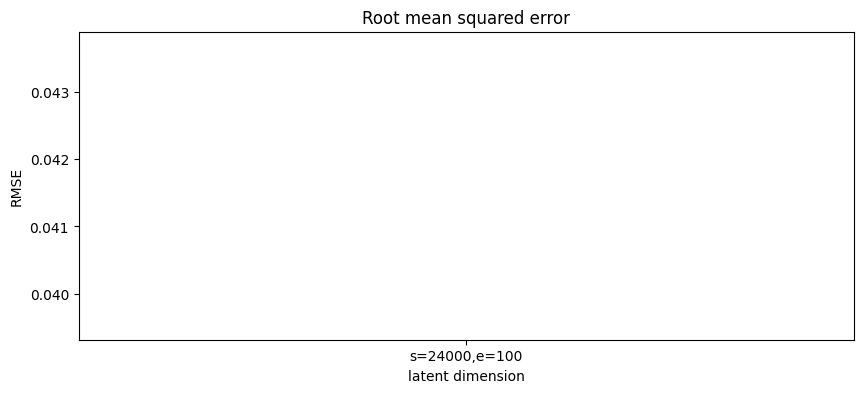

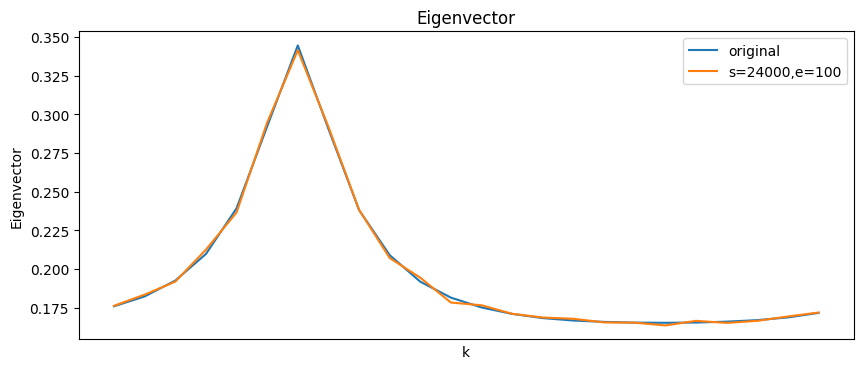

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-09/version_0/'
eval_trainer = init_trainer(device_type='cpu', devices='auto', batch_size=4096, num_dataloader_workers=4)
test_file = 'tp0.020000_mu0.080000.h5'
test_files = ['tp0.020000_mu0.080000.h5', 'tp0.220000_mu0.880000.h5', 'tp0.350000_mu1.400000.h5']
test_file6d = '../../../frgs_6d/' + test_file
vertex6 = AutoEncoderVertex24x6Dataset.load_from_file(test_file6d)
info = [{'save_path': save_path, 'hidden_dims': eval_trainer.config.hidden_dims}]
keys = ['s=24000,e=1000']
i = 18
axis = eval_trainer.config.construction_axis
nrows, ncols = 1, 2
slice_at = (i, i, i, i)
verteval.evaluate_and_report(info, test_file6d, eval_trainer, vertex6, slice_at, axis, keys, nrows, ncols, 
                             predict_func=trainer.predict)

In [44]:
# save_path = trainer.config.save_path
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-09/version_0/'
pc = PhaseClassification(save_path, pc_models, 13)

In [ ]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/30 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

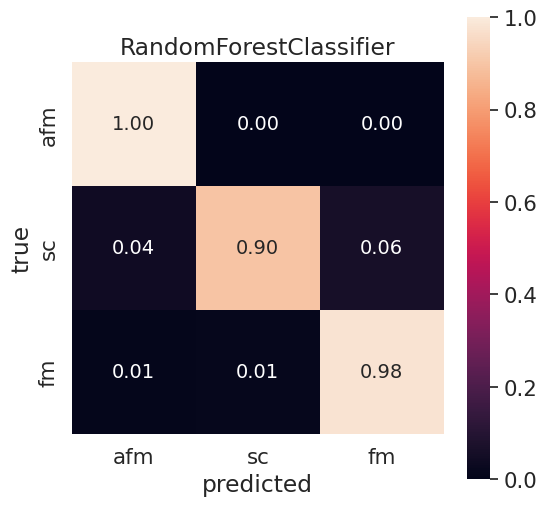

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9575645833333333),
   'prec': 0.9575645833333334,
   'rec': 0.9575645833333334,
   'f1': 0.9575645833333334},
  array([[1.        , 0.        , 0.        ],
         [0.04244375, 0.89509375, 0.0624625 ],
         [0.00789375, 0.01450625, 0.9776    ]]))}

In [47]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'1-3_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 04-2 Train/Test-split within each phase

* determine how well classification works for each phase

In [20]:
train_dataset = make_dataset(subset=0.8, subset_type='phase')

Loading vertex data:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
trainer = init_trainer(train_dataset)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_2'

### 04-2-0 default

In [21]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_2'
pc = PhaseClassification(save_path, pc_models, 20)

In [22]:
pc.train(train_dataset)

Encode vertex samples:   0%|          | 0/30 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/51 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

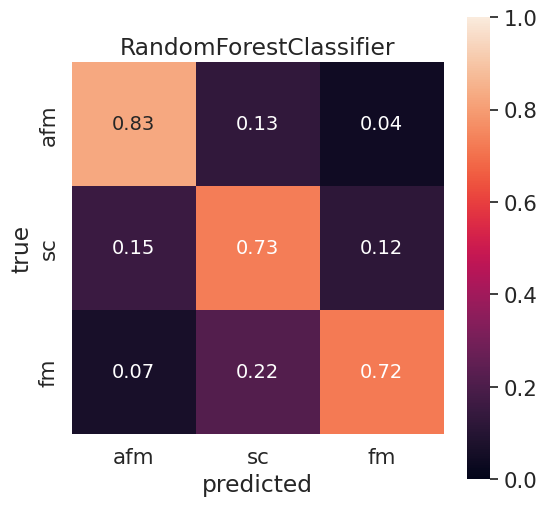

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.758268660968661),
   'prec': 0.7639607843137255,
   'rec': 0.7639607843137255,
   'f1': 0.7639607843137255},
  array([[0.82765   , 0.129575  , 0.042775  ],
         [0.15265385, 0.72796154, 0.11938462],
         [0.06530556, 0.2155    , 0.71919444]]))}

In [23]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 04-2-1 train classifier on uncompressed vertex-samples

In [24]:
pc = PhaseClassification(None, pc_models, 21)

In [25]:
pc.train(train_dataset)

Load vertex samples:   0%|          | 0/30 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Load vertex samples:   0%|          | 0/51 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

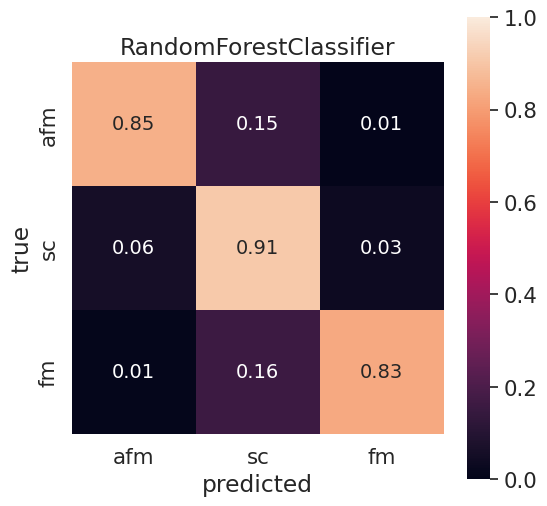

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.8625064814814815),
   'prec': 0.8573235294117647,
   'rec': 0.8573235294117647,
   'f1': 0.8573235294117647},
  array([[0.846575  , 0.1472    , 0.006225  ],
         [0.05630769, 0.909     , 0.03469231],
         [0.00822222, 0.15983333, 0.83194444]]))}

In [26]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'2-1_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 04-2-2 train with Neural Network

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_2'
in_dim = 32
net = phase_classification.NeuralNetClassifier(in_dim, [24, 12], 3, batch_size=config_kwargs['batch_size'], 
                                               num_workers=config_kwargs['num_dataloader_workers'], max_epochs=config_kwargs['epochs'])
pc = PhaseClassification(save_path, [net], 22)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Model NeuralNetClassifier(in_dim=32, hidden_dims=[14], batch_size=8192, num_workers=8, max_epochs=1000) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/21 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

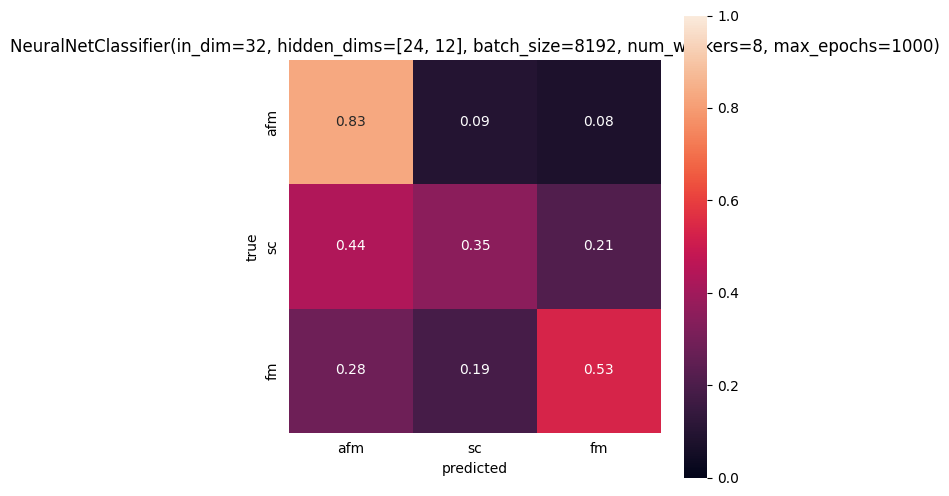

{'NeuralNetClassifier(in_dim=32, hidden_dims=[24, 12], batch_size=8192, num_workers=8, max_epochs=1000)': ({'acc': np.float64(0.5701208333333333),
   'prec': 0.6470952380952381,
   'rec': 0.6470952380952381,
   'f1': 0.6470952380952381},
  array([[0.82805   , 0.0939    , 0.07805   ],
         [0.43516667, 0.35      , 0.21483333],
         [0.2820625 , 0.185625  , 0.5323125 ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'2-2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 04-3 Use vertices from SC-phase as test set

* determine how well the phase can be extrapolated from latent space

In [ ]:
ae_train_dataset = make_dataset(subset=0.8, subset_type=['afm', 'fm'])
train_dataset = make_dataset(subset=0.8)
nce_train_dataset = make_dataset(subset=0.8, sample_count_per_vertex=train_samples_per_vertex // 4, 
                                 dataset_class=AutoEncoder24x6InfoNCEDataset)

In [ ]:
trainer = init_trainer(ae_train_dataset)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'

In [6]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'

### 04-3-1 Exclude SC-phase from classifier-training

In [ ]:
ae_nce_train_dataset = make_dataset(subset=0.8, subset_type=['afm', 'fm'], sample_count_per_vertex=train_samples_per_vertex // 4, 
                                    dataset_class=AutoEncoder24x6InfoNCEDataset)

In [8]:
pc = PhaseClassification(save_path, pc_models, 3)

In [9]:
pc.train(ae_nce_train_dataset)

Encode vertex samples:   0%|          | 0/24 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/15 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

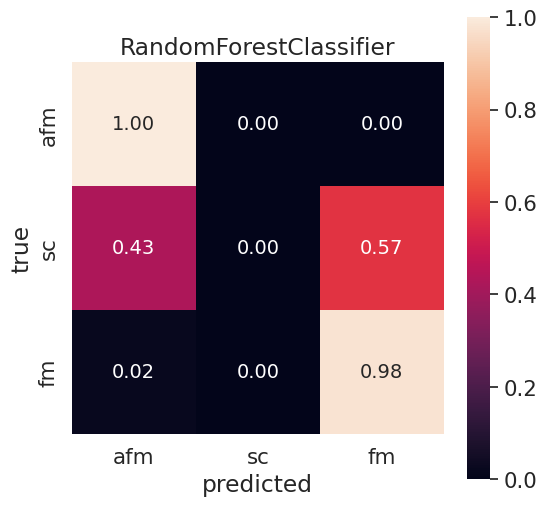

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.6588875),
   'prec': 0.6588875,
   'rec': 0.6588875,
   'f1': 0.6588875},
  array([[9.994500e-01, 0.000000e+00, 5.500000e-04],
         [4.286750e-01, 0.000000e+00, 5.713250e-01],
         [2.278750e-02, 0.000000e+00, 9.772125e-01]]))}

In [10]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-1_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 04-3-2 Include SC-phase in classifier training

#### 04-3-2-0 default

In [11]:
pc = PhaseClassification(save_path, pc_models, 40)

In [12]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/36 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/15 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

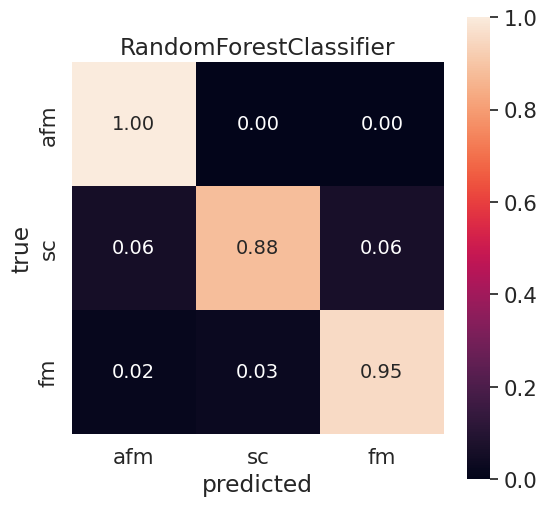

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.94485625),
   'prec': 0.94485625,
   'rec': 0.94485625,
   'f1': 0.94485625},
  array([[9.9906250e-01, 5.9375000e-04, 3.4375000e-04],
         [5.5437500e-02, 8.8169375e-01, 6.2868750e-02],
         [1.6756250e-02, 2.9431250e-02, 9.5381250e-01]]))}

In [13]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 04-3-2-1 train with Neural Network

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'
in_dim = 32
net = phase_classification.NeuralNetClassifier(in_dim, [24, 12], 3, batch_size=config_kwargs['batch_size'], 
                                               num_workers=config_kwargs['num_dataloader_workers'], max_epochs=config_kwargs['epochs'])
pc = PhaseClassification(save_path, [net], 41)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Model NeuralNetClassifier(in_dim=32, hidden_dims=[24, 12], batch_size=8192, num_workers=8, max_epochs=1000) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/10 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

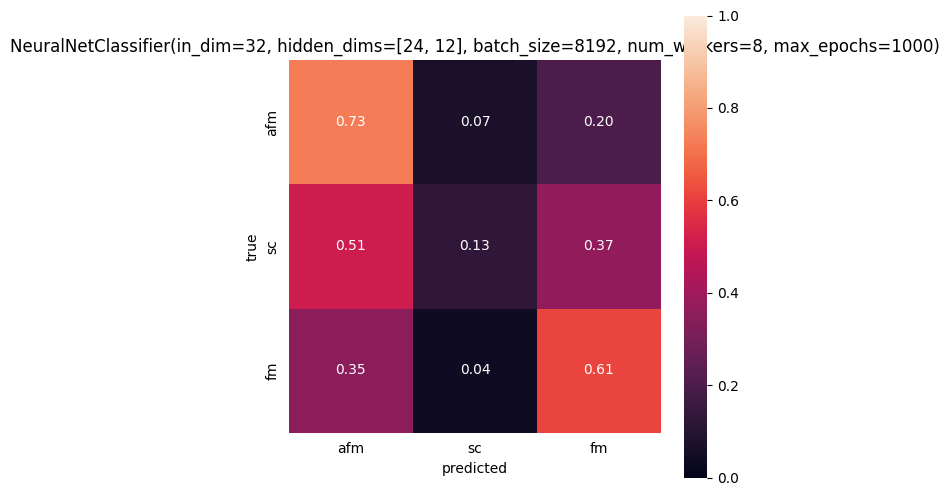

{'NeuralNetClassifier(in_dim=32, hidden_dims=[24, 12], batch_size=8192, num_workers=8, max_epochs=1000)': ({'acc': np.float64(0.49009722222222224),
   'prec': 0.5024,
   'rec': 0.5024,
   'f1': 0.5024},
  array([[0.7285    , 0.06866667, 0.20283333],
         [0.5055    , 0.12866667, 0.36583333],
         [0.350125  , 0.03675   , 0.613125  ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-1_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 04-3-2-2 Use contrastive Autoencoder and classifer on latent space (exclude SC)

In [ ]:
ae_nce_train_dataset = make_dataset(subset=0.8, subset_type=['afm', 'fm'], sample_count_per_vertex=train_samples_per_vertex // 4, 
                                    dataset_class=AutoEncoder24x6InfoNCEDataset, return_filepaths=False)

In [ ]:
trainer = init_trainer(ae_nce_train_dataset, model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', batch_size=4096)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [19]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-15/version_2'

In [20]:
# save_path = trainer.config.save_path
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-15/version_2'
pc = PhaseClassification(save_path, pc_models, 42)

In [23]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/71 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/30 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

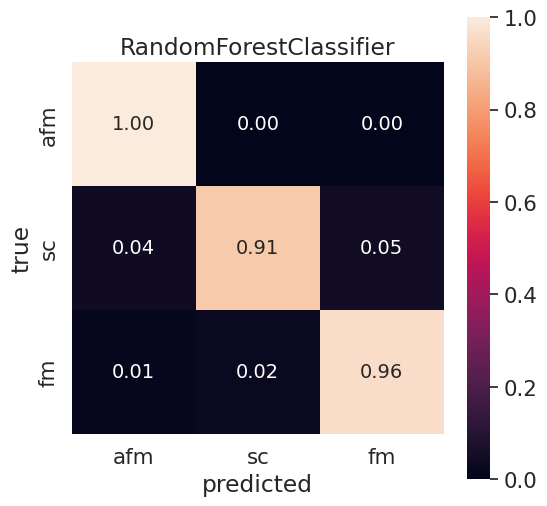

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.9582),
   'prec': 0.9582,
   'rec': 0.9582,
   'f1': 0.9582},
  array([[9.997875e-01, 8.750000e-05, 1.250000e-04],
         [4.290625e-02, 9.116875e-01, 4.540625e-02],
         [1.330000e-02, 2.357500e-02, 9.631250e-01]]))}

In [24]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 04-3-2-3 Use contrastive Autoencoder and classifer on latent space (exclude AFM)

In [ ]:
ae_nce_train_dataset = make_dataset(subset=0.8, subset_type=['sc', 'fm'], sample_count_per_vertex=train_samples_per_vertex // 4, 
                                    dataset_class=AutoEncoder24x6InfoNCEDataset, return_filepaths=False)

In [ ]:
trainer = init_trainer(ae_nce_train_dataset, model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', batch_size=4096)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4095_2025-05-10/version_1'

In [41]:
# save_path = trainer.config.save_path
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4095_2025-05-10/version_1'
pc = PhaseClassification(save_path, pc_models, 43)

In [42]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/41 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/51 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

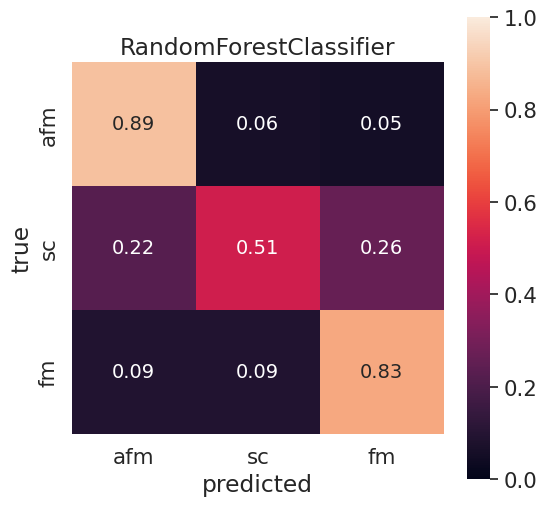

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.7431824786324787),
   'prec': 0.7714411764705882,
   'rec': 0.7714411764705882,
   'f1': 0.7714411764705882},
  array([[0.8889    , 0.0586    , 0.0525    ],
         [0.22315385, 0.51323077, 0.26361538],
         [0.08602778, 0.08655556, 0.82741667]]))}

In [43]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-3_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 04-3-2-4 Use contrastive Autoencoder and classifer on latent space (exclude FM)

In [ ]:
ae_nce_train_dataset = make_dataset(subset=0.8, subset_type=['afm', 'sc'], sample_count_per_vertex=train_samples_per_vertex // 4, 
                                    dataset_class=AutoEncoder24x6InfoNCEDataset, return_filepaths=False)

In [ ]:
trainer = init_trainer(ae_nce_train_dataset, model_wrapper='VertexWrapper24x6InfoNCE', model_name='ContrastiveAutoEncoder', batch_size=4096)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4095_2025-05-12/version_0'

In [44]:
# save_path = trainer.config.save_path
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4095_2025-05-12/version_0'
pc = PhaseClassification(save_path, pc_models, 44)

In [45]:
pc.train(nce_train_dataset)

Encode vertex samples:   0%|          | 0/41 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

Encode vertex samples:   0%|          | 0/51 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

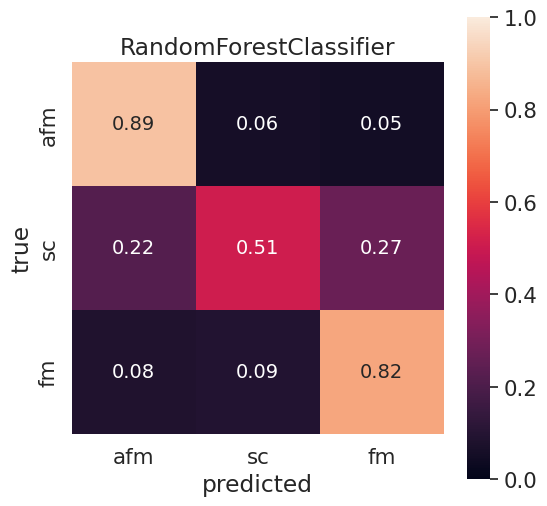

{'RandomForestClassifier(n_jobs=-1, random_state=14)': ({'acc': np.float64(0.7417979344729345),
   'prec': 0.7706470588235295,
   'rec': 0.7706470588235295,
   'f1': 0.7706470588235295},
  array([[0.893725  , 0.056275  , 0.05      ],
         [0.21876923, 0.50830769, 0.27292308],
         [0.08491667, 0.09172222, 0.82336111]]))}

In [46]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-4_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## convergence

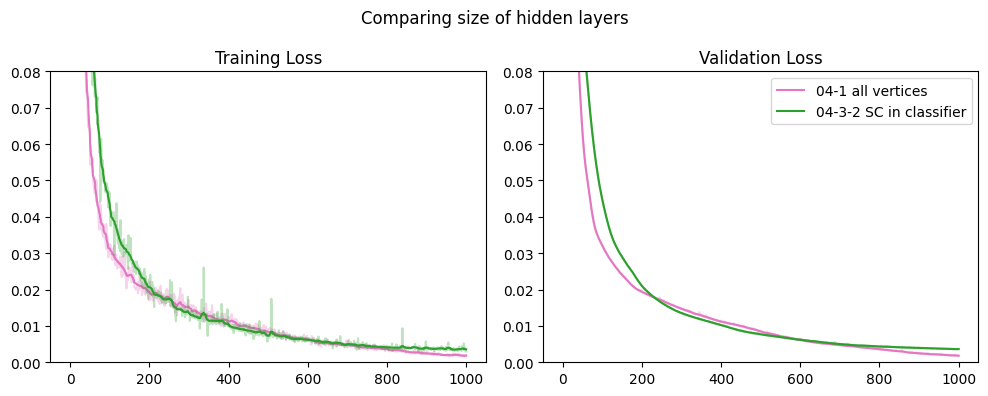

In [ ]:
train_data_files = ['../../saves/tensorboard/BS8192_2025-03-22_version_1_train.csv', 
                    '../../saves/tensorboard/BS8192_2025-03-22_version_3_train.csv']
val_data_files = ['../../saves/tensorboard/BS8192_2025-03-22_version_1_val.csv', 
                    '../../saves/tensorboard/BS8192_2025-03-22_version_3_val.csv']
labels = ['04-1 all vertices', '04-3-2 SC only in classifier']
title = 'Comparing size of hidden layers'

vis.plot_training_progress(train_data_files, val_data_files, labels, title, y_max=0.08)

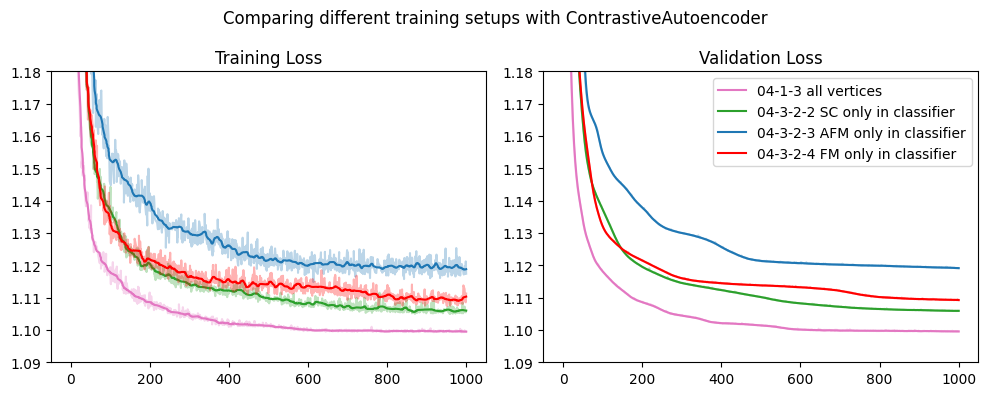

In [4]:
train_data_files = ['../../saves/tensorboard/BS4096_2025-05-03_version_0_train.csv',
                    '../../saves/tensorboard/BS4096_2025-05-07_version_0_train.csv',
                    '../../saves/tensorboard/BS4096_2025-05-07_version_1_train.csv',
                    '../../saves/tensorboard/BS4096_2025-05-07_version_2_train.csv',]
val_data_files = ['../../saves/tensorboard/BS4096_2025-05-03_version_0_val.csv',
                  '../../saves/tensorboard/BS4096_2025-05-07_version_0_val.csv',
                  '../../saves/tensorboard/BS4096_2025-05-07_version_1_val.csv',
                  '../../saves/tensorboard/BS4096_2025-05-07_version_2_val.csv',]
labels = ['04-1-3 all vertices', '04-3-2-2 SC only in classifier', '04-3-2-3 AFM only in classifier', '04-3-2-4 FM only in classifier']
title = 'Comparing different training setups with ContrastiveAutoencoder'

vis.plot_training_progress(train_data_files, val_data_files, labels, title, y_max=1.18, y_min=1.09)

# 05 Phase regression

In [ ]:
mode = 'r'
pc_models = [
    # svm.SVR(), 
    # phase_classification.PolynomialRegression.new(degree=2),
    # phase_classification.PolynomialRegression.new(degree=4),
    ensemble.RandomForestRegressor(n_jobs=-1, random_state=seed + 1),
]

## 05-1 All vertices

In [ ]:
train_dataset = make_dataset()

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_1'
pc = PhaseClassification(save_path, pc_models, 1, mode)

In [ ]:
pc.train(train_dataset)

Model PolynomialRegression(degree=4) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


Load data:   0%|          | 0/51 [00:00<?, ?it/s]

Predict:   0%|          | 0/3 [00:00<?, ?it/s]

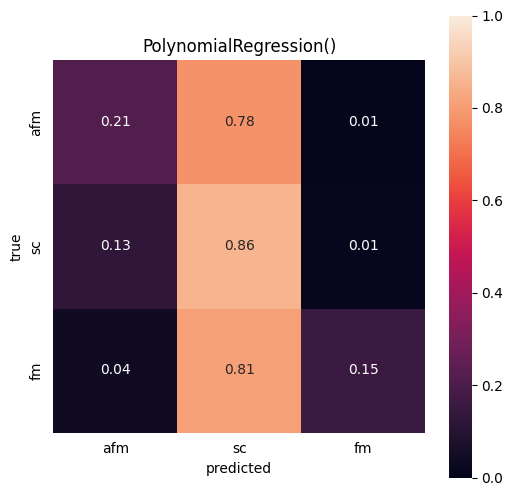

Skipping model PolynomialRegression(degree=4), which could not be fitted.


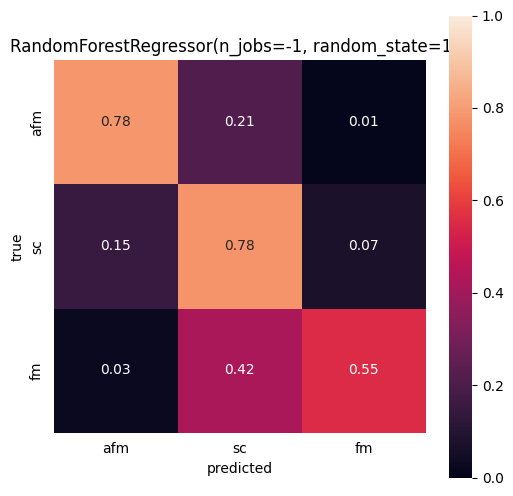

{'PolynomialRegression()': ({'rmse': 0.1356355612791372,
   'acc': np.float64(0.40874280626780624),
   'prec': 0.357,
   'rec': 0.357,
   'f1': 0.357},
  array([[0.214175  , 0.776425  , 0.0094    ],
         [0.12661538, 0.85869231, 0.01469231],
         [0.04130556, 0.80533333, 0.15336111]])),
 'PolynomialRegression(degree=4)': (None, None),
 'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.07988664543969688,
   'acc': np.float64(0.7046866096866097),
   'prec': 0.7005098039215686,
   'rec': 0.7005098039215686,
   'f1': 0.7005098039215686},
  array([[0.783     , 0.20825   , 0.00875   ],
         [0.14946154, 0.77861538, 0.07192308],
         [0.02686111, 0.42069444, 0.55244444]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'1_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 05-2 Train/Test-split within each phase

In [ ]:
train_dataset = make_dataset(subset=0.8, subset_type='phase')

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_2'
pc = PhaseClassification(save_path, pc_models, 2, mode)

In [ ]:
path_train = '../../../frgs_6d'
train_files = pc.vertex_trainer.dataset.file_paths
test_files = [f for f in glob.glob(f"{path_train}/*.h5") if f not in train_files]
pc.train(train_dataset)

Load data:   0%|          | 0/11 [00:00<?, ?it/s]

Predict:   0%|          | 0/2 [00:00<?, ?it/s]

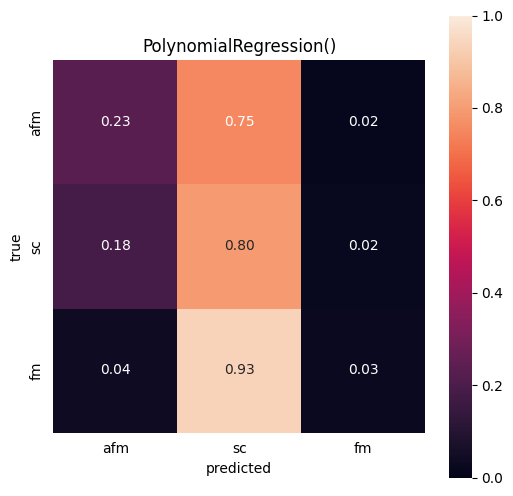

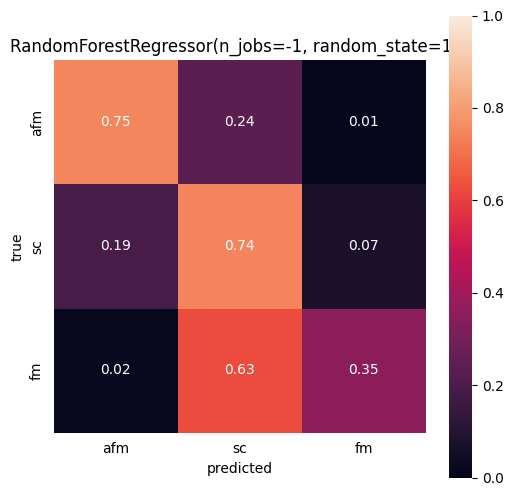

{'PolynomialRegression()': ({'rmse': 0.12149857187464187,
   'acc': np.float64(0.35297222222222224),
   'prec': 0.31272727272727274,
   'rec': 0.31272727272727274,
   'f1': 0.31272727272727274},
  array([[0.233625  , 0.750875  , 0.0155    ],
         [0.1835    , 0.79566667, 0.02083333],
         [0.036125  , 0.93425   , 0.029625  ]])),
 'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.07506055254683623,
   'acc': np.float64(0.6148611111111112),
   'prec': 0.6030454545454546,
   'rec': 0.6030454545454546,
   'f1': 0.6030454545454546},
  array([[0.749875  , 0.238     , 0.012125  ],
         [0.1875    , 0.74483333, 0.06766667],
         [0.023125  , 0.627     , 0.349875  ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'2_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 05-3 Use vertices from SC-phase as test set

* determine how well the phase can be extrapolated from latent space

In [ ]:
ae_train_dataset = make_dataset(subset=0.8, subset_type=['afm', 'fm'])
train_dataset = make_dataset(subset=0.8)

### 05-3-1 Exclude SC-phase from classifier-training

In [4]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'
pc = PhaseClassification(save_path, pc_models, 3, mode)

Model PolynomialRegression() is not fitted and could not be loaded. Call train() before using the PhaseClassifier.
Model RandomForestRegressor(n_jobs=-1, random_state=13) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


In [ ]:
pc.train(ae_train_dataset)

Load data:   0%|          | 0/30 [00:00<?, ?it/s]

Fit models:   0%|          | 0/2 [00:00<?, ?it/s]

Load data:   0%|          | 0/21 [00:00<?, ?it/s]

Predict:   0%|          | 0/2 [00:00<?, ?it/s]

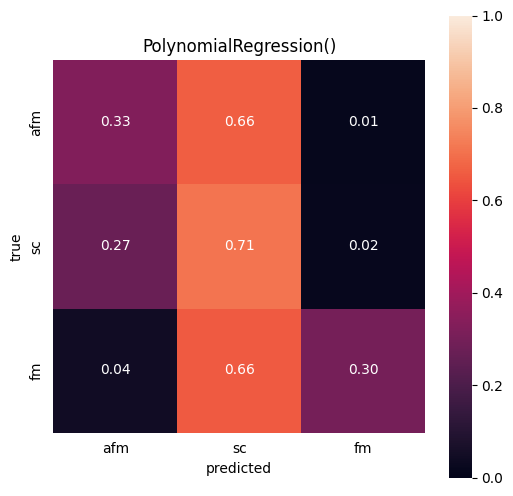

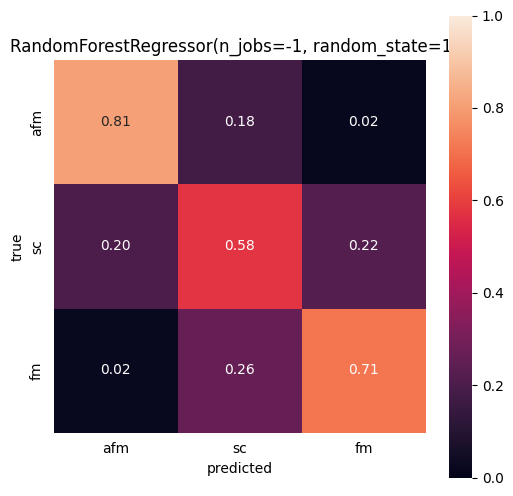

{'PolynomialRegression()': ({'rmse': 0.10650268940432761,
   'acc': np.float64(0.44498397435897435),
   'prec': 0.5581666666666667,
   'rec': 0.5581666666666667,
   'f1': 0.5581666666666667},
  array([[0.32525   , 0.6605    , 0.01425   ],
         [0.27176923, 0.70907692, 0.01915385],
         [0.043875  , 0.6555    , 0.300625  ]])),
 'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.07531124258543279,
   'acc': np.float64(0.699451923076923),
   'prec': 0.6466428571428572,
   'rec': 0.6466428571428572,
   'f1': 0.6466428571428572},
  array([[0.807875  , 0.176375  , 0.01575   ],
         [0.20134615, 0.57623077, 0.22242308],
         [0.021     , 0.26475   , 0.71425   ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-1_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

### 05-3-2 Include SC-phase in classifier training

#### 05-3-2-0 default

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-22/version_3'
pc = PhaseClassification(save_path, pc_models, 40, mode)

In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/10 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

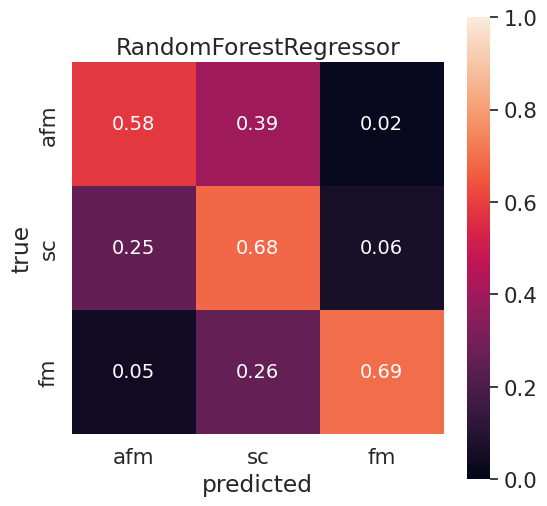

{'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.09164959511912749,
   'acc': np.float64(0.6537083333333333),
   'prec': 0.65775,
   'rec': 0.65775,
   'f1': 0.65775},
  array([[0.58416667, 0.393     , 0.02283333],
         [0.2545    , 0.68283333, 0.06266667],
         [0.04525   , 0.260625  , 0.694125  ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 05-3-2-1 Use contrastive Autoencoder and classifer on latent space (exclude SC)

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-09/version_1'
pc = PhaseClassification(save_path, pc_models, 41, mode)

In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/11 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

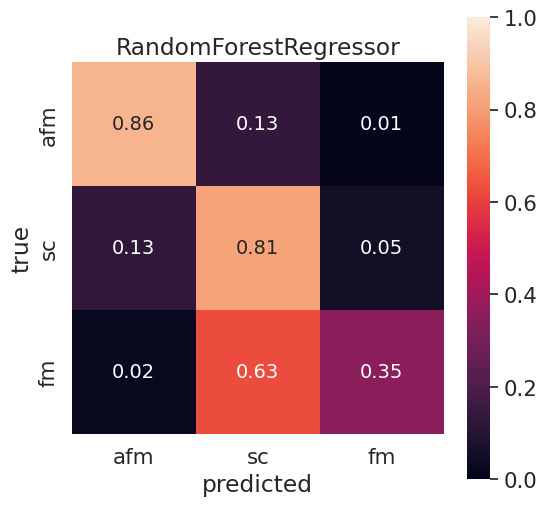

{'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.06831853098138563,
   'acc': np.float64(0.6745694444444444),
   'prec': 0.6618181818181819,
   'rec': 0.6618181818181819,
   'f1': 0.6618181818181819},
  array([[0.856875  , 0.134375  , 0.00875   ],
         [0.13216667, 0.81483333, 0.053     ],
         [0.022375  , 0.625625  , 0.352     ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-1_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 05-3-2-2 Use contrastive Autoencoder and classifer on latent space (exclude AFM)

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-09/version_2'
pc = PhaseClassification(save_path, pc_models, 42, mode)

In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/11 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

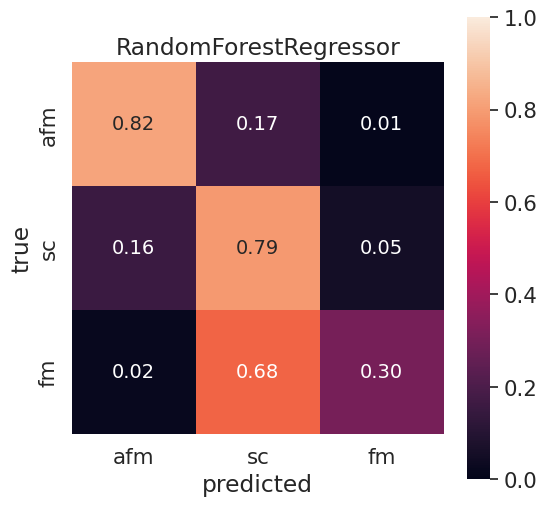

{'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.07567110498430332,
   'acc': np.float64(0.6369027777777777),
   'prec': 0.6229545454545454,
   'rec': 0.6229545454545454,
   'f1': 0.6229545454545454},
  array([[0.818375  , 0.171125  , 0.0105    ],
         [0.15583333, 0.79033333, 0.05383333],
         [0.022875  , 0.675125  , 0.302     ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-2_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

#### 05-3-2-3 Use contrastive Autoencoder and classifer on latent space (exclude FM)

In [ ]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS4096_2025-05-09/version_3'
pc = PhaseClassification(save_path, pc_models, 43, mode)

In [ ]:
pc.train(train_dataset)

Load data:   0%|          | 0/11 [00:00<?, ?it/s]

Predict:   0%|          | 0/1 [00:00<?, ?it/s]

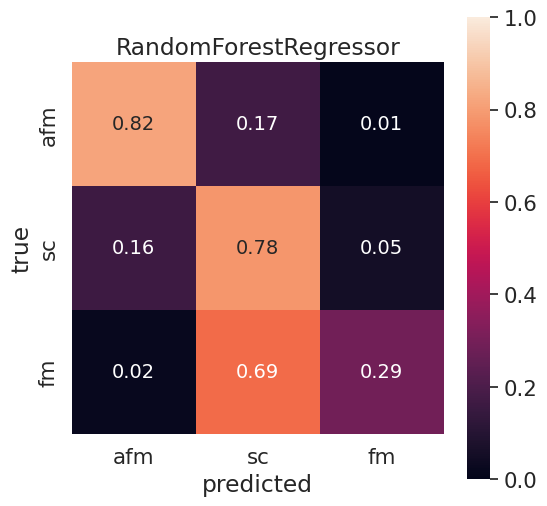

{'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.07628737037734956,
   'acc': np.float64(0.6312361111111112),
   'prec': 0.6172727272727273,
   'rec': 0.6172727272727273,
   'f1': 0.6172727272727273},
  array([[0.818875  , 0.17125   , 0.009875  ],
         [0.16133333, 0.78483333, 0.05383333],
         [0.020125  , 0.689875  , 0.29      ]]))}

In [ ]:
model_scores = pc.evaluate_classifiers(test_dataset, print_conf_mat=True)
with open(f'3-2-3_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

# 0x U-Net

In [ ]:
info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32]
config_kwargs = {'path_train': '../../../frgs_6d', 
                 'model_name': 'UNetVertex',
                 'hidden_dims': hidden_dims,
                 'epochs': 1000,
                 'sample_count_per_vertex': 2000, 
                 'test_ratio': 0.2, 
                 'subset': -1, 
                 'subset_shuffle': False, 
                 'devices': 'auto', 
                 'num_dataloader_workers': 8, 
                 'strategy': 'auto', 
                 'batch_size': 4096}


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## train

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, hidden_dims)

## evaluate prediction

In [ ]:
test_file = 'tp0.020000_mu0.080000.h5'
test_file3d = '../../../frgs/' + test_file
test_file6d = '../../../frgs_6d/' + test_file

info = verteval.load_info_dict(info_fn)

vertex3 = AutoEncoderVertexDataset.load_from_file(test_file3d)
vertex6 = AutoEncoderVertex24x6Dataset.load_from_file(test_file6d)

keys = [f'n={x['latent_dim']}' for x in info]
trainer = init_trainer(device_type='cpu', batch_size=1024, num_dataloader_workers=8)

i = 18
axis = trainer.config.construction_axis
k, other_k = (axis + 1) // 2, 3
slice_idx_3d = i * 24 + i
nrows, ncols = 2, 3

### predict 24x24 slice

In [ ]:
# RESULTS FOR 2-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i, i, i), axis, keys, nrows, ncols, 
                             trainer.predict_slice2d, fixed_idcs=(i, i, i, i))

### predict 576x576 slice

In [ ]:
# RESULTS FOR 4-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i), (k, other_k), keys, nrows, ncols, 
                             trainer.predict_slice4d, fixed_idcs=(i, i), other_k=other_k)

### predict full vertex

In [ ]:
# RESULTS FOR 6-DIMENSIONAL PREDICTION
# for 6d-data
slice_at = (i, i, i, i)
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, slice_at, axis, keys, nrows, ncols, 
                             predict_func=trainer.predict)

In [ ]:
# for 3d-data
slice_at = slice_idx_3d
verteval.evaluate_and_report(info, test_file3d, trainer, vertex3, slice_at, axis, keys, nrows, ncols, 
                             load_func=trainer.load_prediction)

# ---